# 02 — Baseline модель: Logistic Regression + TF-IDF

**Быкова Анна**  
**Гипотеза:** TF-IDF признаки на биграммах + Logistic Regression смогут отделить токсичные комментарии от нетоксичных лучше случайного угадывания.  
**Обоснование выбора baseline:** LogisticRegression — стандартная отправная точка для текстовых задач. Быстро обучается, интерпретируема (веса = важность слов), хорошо работает с разреженными матрицами TF-IDF.

## 1. Импорты

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print('Импорты загружены')

Импорты загружены


## 2. Загрузка обработанных данных

In [21]:
df = pd.read_csv(
    '/content/processed_data3.csv',
    encoding='utf-8',
    encoding_errors='replace',
    on_bad_lines='skip', # Skip malformed lines
    engine='python' # Required for on_bad_lines
)
print(f'Загружено строк: {len(df)}')
print(f'Распределение классов:')
print(df['toxic'].value_counts())
df.head()

Загружено строк: 126493
Распределение классов:
toxic
0.0    106985
1.0     19507
Name: count, dtype: int64


,text,toxic,char_count,word_count,clean_text
0,скотина! что сказать,1.0,20.0,3.0,скотина что сказать
1,я сегодня проезжала по рабочей и между домами ...,0.0,180.0,29.0,я сегодня проезжала по рабочей и между домами ...
2,очередной лохотрон. зачем придумывать очередно...,0.0,379.0,54.0,очередной лохотрон зачем придумывать очередной...
3,"ретро дежавю ... сложно понять чужое сердце , ...",0.0,72.0,12.0,ретро дежавю сложно понять чужое сердце лиш ощ...
4,а когда мы статус агрогородка получили?,0.0,39.0,6.0,а когда мы статус агрогородка получили


## 3. Train/Test разделение

Используем `stratify=y`, чтобы сохранить пропорцию классов в обеих выборках — критично при дисбалансе.

In [22]:
# Удаляем строки с NaN из нужных столбцов перед разделением
df.dropna(subset=['clean_text', 'toxic'], inplace=True)

X = df['clean_text']
y = df['toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # сохраняем пропорцию классов
)

print(f'Train: {len(X_train)} примеров')
print(f'Test:  {len(X_test)} примеров')
print(f'\nКласс. баланс в train: {y_train.value_counts().to_dict()}')
print(f'Класс. баланс в test:  {y_test.value_counts().to_dict()}')

# Убедимся, что директория '../data' существует перед сохранением
os.makedirs('../data', exist_ok=True)

# Сохраняем разбивку для использования в ноутбуке 03
pd.DataFrame({'index': X_train.index}).to_csv('/content/train_indices.csv', index=False)
pd.DataFrame({'index': X_test.index}).to_csv('/content/test_indices.csv', index=False)

Train: 101193 примеров
Test:  25299 примеров

Класс. баланс в train: {0.0: 85587, 1.0: 15606}
Класс. баланс в test:  {0.0: 21398, 1.0: 3901}


## 4. Векторизация: TF-IDF

- `max_features=10000` — берём 10k самых частотных n-грамм
- `ngram_range=(1, 2)` — уniграммы и биграммы: «не хорошо» лучше захватывает смысл, чем «хорошо» отдельно
- `sublinear_tf=True` — логарифмическое масштабирование частоты, уменьшает влияние очень частых слов

In [24]:
# Векторайзер обучаем ТОЛЬКО на train — это важно для корректной оценки
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2  # игнорируем слова, встречающиеся менее 2 раз
)

X_train_vec = vectorizer.fit_transform(X_train)  # fit + transform
X_test_vec  = vectorizer.transform(X_test)        # только transform!

print(f'Форма матрицы признаков (train): {X_train_vec.shape}')
print(f'Форма матрицы признаков (test):  {X_test_vec.shape}')

# Сохраняем векторайзер — нужен для воспроизводимости и ноутбука 03
joblib.dump(vectorizer, '/content/vectorizer.pkl')
print('Векторайзер сохранён: /content/vectorizer.pkl')

Форма матрицы признаков (train): (101193, 10000)
Форма матрицы признаков (test):  (25299, 10000)
Векторайзер сохранён: /content/vectorizer.pkl


## 5. Обучение Baseline модели

In [25]:
model_baseline = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'  # компенсируем дисбаланс классов
)

model_baseline.fit(X_train_vec, y_train)
print('Baseline модель обучена')

Baseline модель обучена


## 6. Оценка качества

In [26]:
y_pred = model_baseline.predict(X_test_vec)
y_prob = model_baseline.predict_proba(X_test_vec)[:, 1]

f1 = f1_score(y_test, y_pred, average='macro')
roc = roc_auc_score(y_test, y_prob)

print('Отчёт классификации')
print(classification_report(y_test, y_pred,
                             target_names=['Нетоксичный', 'Токсичный']))
print(f'F1-macro:  {f1:.4f}')
print(f'ROC-AUC:   {roc:.4f}')

# Сохраняем метрики для сравнения
results = pd.DataFrame([{'model': 'Baseline (LogReg)', 'f1_macro': f1, 'roc_auc': roc}])
results.to_csv('/content/results.csv', index=False)
print('\nМетрики сохранены: data/results.csv')

Отчёт классификации
              precision    recall  f1-score   support

 Нетоксичный       0.97      0.96      0.96     21398
   Токсичный       0.78      0.85      0.82      3901

    accuracy                           0.94     25299
   macro avg       0.88      0.90      0.89     25299
weighted avg       0.94      0.94      0.94     25299

F1-macro:  0.8903
ROC-AUC:   0.9609

Метрики сохранены: data/results.csv


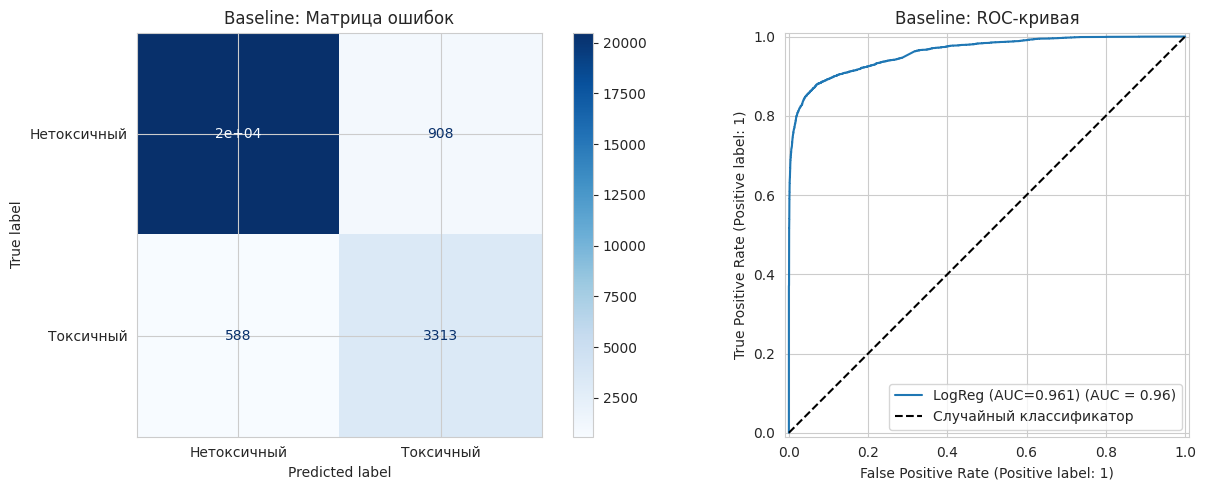

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Нетоксичный', 'Токсичный'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Baseline: Матрица ошибок')

# ROC-кривая
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                  name=f'LogReg (AUC={roc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[1].set_title('Baseline: ROC-кривая')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/baseline_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Интерпретация: самые влиятельные признаки

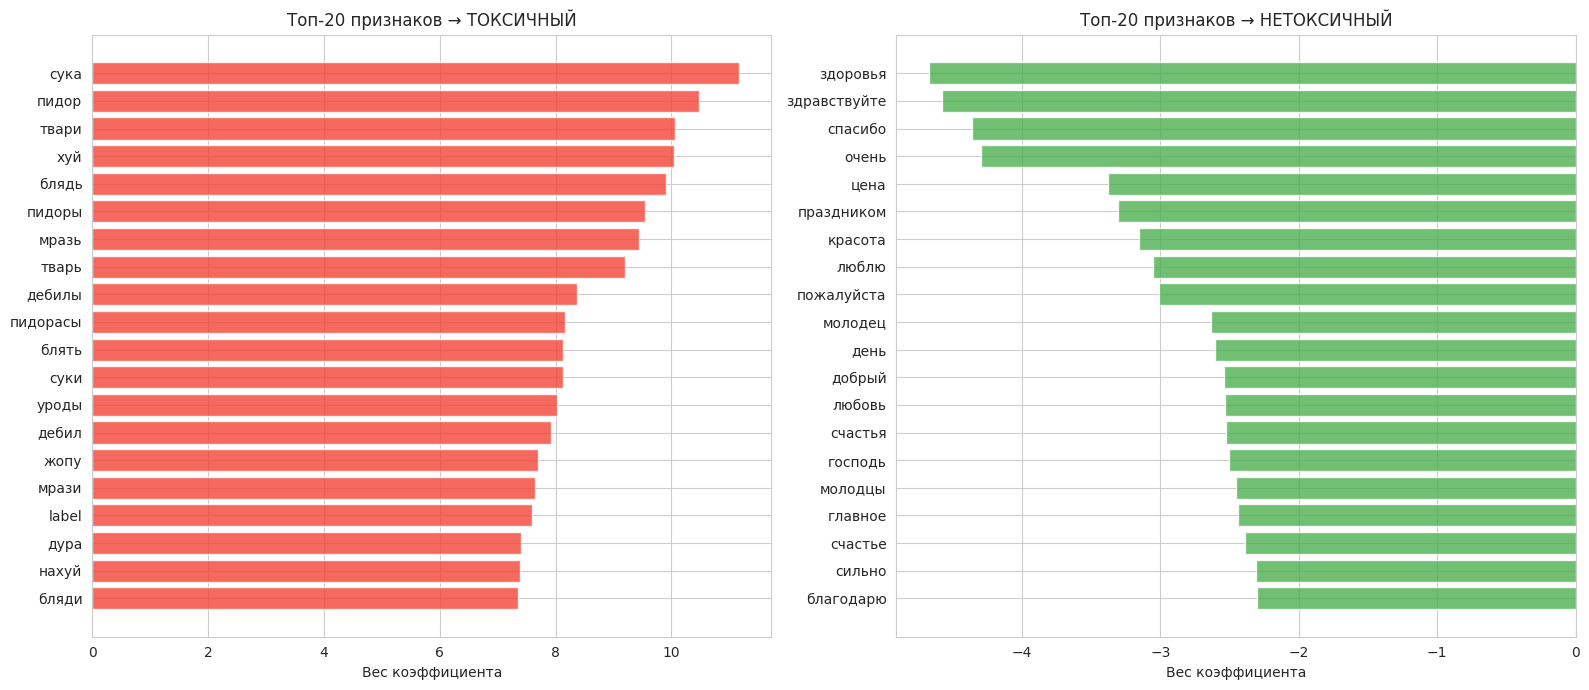

In [28]:
feature_names = vectorizer.get_feature_names_out()
coef = model_baseline.coef_[0]

# Топ слов для каждого класса
N = 20
top_toxic_idx   = np.argsort(coef)[-N:][::-1]
top_clean_idx   = np.argsort(coef)[:N]

top_toxic_words  = [(feature_names[i], coef[i]) for i in top_toxic_idx]
top_clean_words  = [(feature_names[i], coef[i]) for i in top_clean_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

words_t, scores_t = zip(*top_toxic_words)
axes[0].barh(words_t[::-1], scores_t[::-1], color='#F44336', alpha=0.8)
axes[0].set_title(f'Топ-{N} признаков → ТОКСИЧНЫЙ')
axes[0].set_xlabel('Вес коэффициента')

words_c, scores_c = zip(*top_clean_words)
axes[1].barh(words_c[::-1], scores_c[::-1], color='#4CAF50', alpha=0.8)
axes[1].set_title(f'Топ-{N} признаков → НЕТОКСИЧНЫЙ')
axes[1].set_xlabel('Вес коэффициента')

plt.tight_layout()
plt.savefig('/content/feature_importance_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Примеры ошибок модели
errors = pd.DataFrame({
    'text': X_test,
    'true': y_test,
    'pred': y_pred
})
errors = errors[errors['true'] != errors['pred']]

print(f'Всего ошибок: {len(errors)}')
print('\n--- False Positives (нетоксичный → помечен как токсичный) ---')
print(errors[errors['true'] == 0]['text'].head(3).to_string())
print('\n--- False Negatives (токсичный → пропущен) ---')
print(errors[errors['true'] == 1]['text'].head(3).to_string())

Всего ошибок: 1496

--- False Positives (нетоксичный → помечен как токсичный) ---
115526    еще как обязать могут всех погонят под одну гр...
70749     ой ёй я тут впервые сбежала с вк там ау захире...
14661                               которая про шишки пишет

--- False Negatives (токсичный → пропущен) ---
107165    жаль убийцу детей донбаса вы о чём он ещё в и ...
56804                          попа просто а хуеть красивая
85468                           пидаросня как и их родители


In [30]:
# Сохраняем модель
joblib.dump(model_baseline, '../data/model_baseline.pkl')
print('Baseline модель сохранена: data/model_baseline.pkl')

Baseline модель сохранена: data/model_baseline.pkl


## Итоги Baseline

| Метрика | Значение |
|---------|----------|
| F1-macro | *0.8903* |
| ROC-AUC  | *0.9609* |

**Анализ ошибок:**
- Модель чаще ошибается на коротких комментариях без явной токсичной лексики
- TF-IDF не учитывает порядок слов и контекст — «не плохой» и «плохой» обрабатываются похоже
- Биграммы частично решают эту проблему, но не полностью

**Следующий шаг:** попробуем LinearSVC с подбором гиперпараметра C — он лучше работает с разреженными текстовыми матрицами.